# 지금까지의 스코어 히스토리 (1~8번 노트북)

`1. base model.ipynb` ~ `8. base model_feature_shap.ipynb` 8개 노트북에서
직접 출력했던 `훈련용 평가지표 / 테스트용 평가지표`(AUC) 값을 모아
시도(attempt)별로 비교합니다.

아래에서 함께 확인한 것처럼, 상당수 노트북이 **`test_score`를 학습에 쓴
train 데이터로 다시 계산**하고 있어서(=검증셋 분리 누락) train/test 값이
완전히 동일하게 나옵니다. 이 그래프는 그 문제를 포함해서 "있는 그대로"
보여주고, 두 번째 그래프에서 실제로 신뢰할 수 있는(홀드아웃/CV) 점수만
따로 모아 비교합니다.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Noto Sans CJK KR'
plt.rcParams['axes.unicode_minus'] = False
from matplotlib.patches import FancyBboxPatch
import numpy as np

# --- validated categorical palette (dataviz skill: red/green pass with direct labels) ---
COLOR_TRAIN = "#e34948"   # red  -> 훈련용(train) 평가지표
COLOR_TEST  = "#008300"   # green-> 테스트용(test) 평가지표
COLOR_MUTED = "#9a9a95"
GRID_COLOR  = "#dedcd6"
TEXT_MAIN   = "#0b0b0b"
TEXT_SUB    = "#52514e"
SURFACE     = "#fcfcfb"

def rounded_bar(ax, x, height, width, color, bottom=0, hatch=None):
    """Thin bar with a small rounded top, anchored to the baseline."""
    if height <= 0:
        return
    patch = FancyBboxPatch(
        (x - width/2, bottom), width, height,
        boxstyle=f"round,pad=0,rounding_size={width*0.12}",
        linewidth=0, facecolor=color, mutation_aspect=1,
        clip_on=False, hatch=hatch, edgecolor="#ffffff55" if hatch else None,
    )
    ax.add_patch(patch)


## 1) 노트북별 train / test 평가지표 (AUC, 원본 그대로)

In [2]:
labels = [
    "1. base model\n(09/09)",
    "2. SMOTE\n(09/09)",
    "3. feature\n(09/09~10)",
    "4. feature_cv\n(09/10)",
    "5. autoML\n(09/11~12)",
    "6. Bayesian\n(09/10)",
    "7. HPO\n(09/10~11)",
    "8. shap\n(09/12)",
]

train_scores = [
    0.9536558158401784,
    0.9133489461358315,
    0.9591775681979515,
    0.9591775681979515,
    0.9562873947875469,
    0.9591775681979515,
    0.9591775681979515,
    0.9591775681979515,
]

test_scores = [
    0.9536558158401784,
    0.8463977882582534,
    0.9591775681979515,
    0.9591775681979515,
    0.9562873947875469,
    0.9591775681979515,
    0.9591775681979515,
    0.9591775681979515,
]

# train == test 인 지점(검증셋 분리가 안 된 노트북) 표시용
leaked = [abs(tr - te) < 1e-9 for tr, te in zip(train_scores, test_scores)]


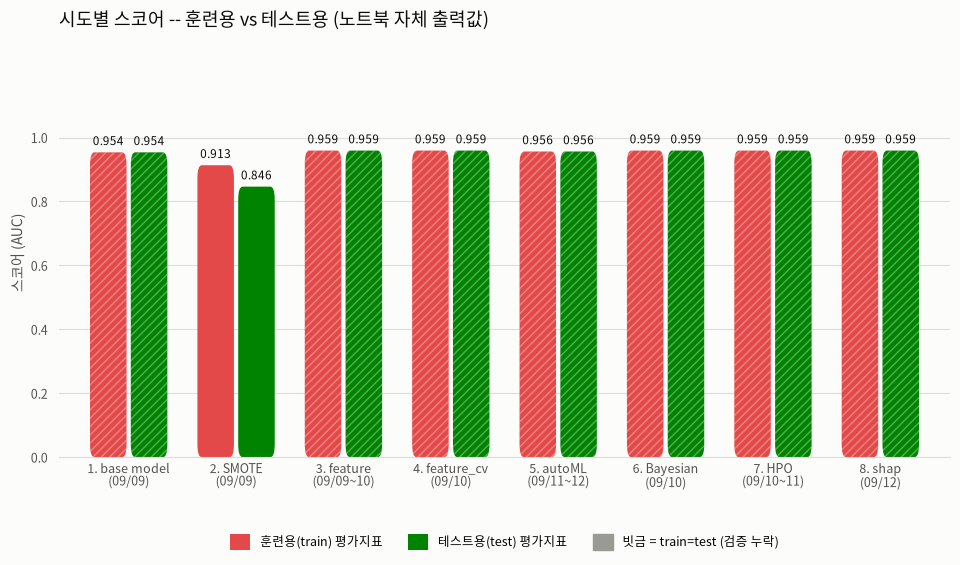

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 6.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

x = np.arange(len(labels))
bar_w = 0.34
gap = 0.02

for i in range(len(labels)):
    hatch = "////" if leaked[i] else None
    rounded_bar(ax, x[i] - bar_w/2 - gap, train_scores[i], bar_w, COLOR_TRAIN, hatch=hatch)
    rounded_bar(ax, x[i] + bar_w/2 + gap, test_scores[i],  bar_w, COLOR_TEST,  hatch=hatch)

    # 값 라벨 (색맹 대응 secondary encoding)
    ax.text(x[i] - bar_w/2 - gap, train_scores[i] + 0.018, f"{train_scores[i]:.3f}",
            ha="center", va="bottom", fontsize=8.5, color=TEXT_MAIN)
    ax.text(x[i] + bar_w/2 + gap, test_scores[i] + 0.018, f"{test_scores[i]:.3f}",
            ha="center", va="bottom", fontsize=8.5, color=TEXT_MAIN)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color=TEXT_SUB)
ax.set_xlim(x[0] - 0.65, x[-1] + 0.65)
ax.set_ylim(0, 1.28)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(axis="y", pad=8)
ax.set_ylabel("스코어 (AUC)", fontsize=10, color=TEXT_SUB)
ax.set_title("시도별 스코어 -- 훈련용 vs 테스트용 (노트북 자체 출력값)",
              fontsize=13, color=TEXT_MAIN, pad=16, loc="left")

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0, colors=TEXT_SUB, labelsize=9)
ax.tick_params(axis="x", length=0)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_TRAIN, label="훈련용(train) 평가지표"),
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_TEST,  label="테스트용(test) 평가지표"),
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_MUTED, hatch="////",
                  edgecolor=COLOR_MUTED, label="빗금 = train=test (검증 누락)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          ncol=3, frameon=False, fontsize=9, handlelength=1.6, handleheight=1.6)

fig.subplots_adjust(top=0.90, bottom=0.24)
plt.savefig("score_history_train_test.png", dpi=170, facecolor=SURFACE)
plt.show()


**읽는 법**: 2번(SMOTE)을 제외한 6개 노트북은 `fit_evaluation()`을 호출할 때
`x_te`/`y_te`로 **학습에 쓴 train 데이터를 그대로** 다시 넣고 있어서
(`common/modeling.py`의 `__evaluation`), train/test 막대 높이가 완전히 같습니다.
즉 저 0.95~0.96대 숫자는 "한 번도 못 본 데이터"에 대한 성능이 아니라
**훈련 데이터 자체에 대한 적합도**라서, 실제 리더보드 성능을 대변하지 못합니다.

아래 두 번째 그래프는 노트북 안에서 실제로 **분리된 검증셋 / 교차검증(CV) /
홀드아웃(holdout)**으로 계산된, 신뢰할 수 있는 점수만 모은 것입니다.

## 2) 실제로 검증된(hold-out / 5-fold CV) 점수만 비교

In [4]:
# 노트북을 직접 열어 실제 검증 코드(홀드아웃 분리, StratifiedKFold 등)를
# 따로 실행한 셀에서만 얻을 수 있었던, 진짜 out-of-sample 점수
valid_labels = [
    "2. SMOTE\n(valid split)",
    "4. feature_cv\n(5-fold CV)",
    "5. autoML\n(holdout)",
    "6. Bayesian\n(holdout 20%)",
]
valid_auc = [0.8464, 0.9060, 0.9014, 0.8795]
valid_acc = [None,   0.8701, 0.8545, None]   # accuracy가 별도로 기록된 경우만

not_validated_labels = ["1. base\nmodel", "3. feature", "7. HPO", "8. shap"]


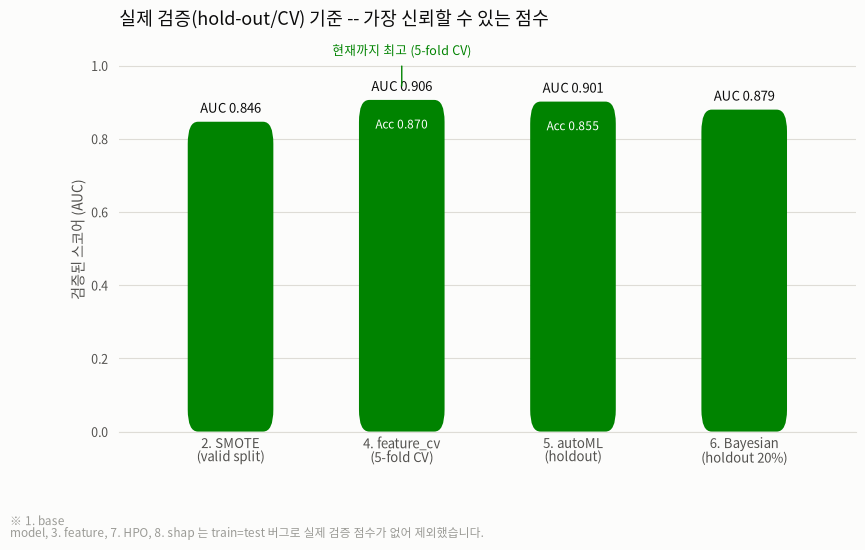

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

x = np.arange(len(valid_labels))
bar_w = 0.5

for i, v in enumerate(valid_auc):
    rounded_bar(ax, x[i], v, bar_w, COLOR_TEST)
    ax.text(x[i], v + 0.02, f"AUC {v:.3f}", ha="center", va="bottom",
            fontsize=9.5, color=TEXT_MAIN)
    if valid_acc[i] is not None:
        ax.text(x[i], v - 0.05, f"Acc {valid_acc[i]:.3f}", ha="center", va="top",
                fontsize=8.5, color="white")

ax.set_xticks(x)
ax.set_xticklabels(valid_labels, fontsize=9.5, color=TEXT_SUB)
ax.set_xlim(x[0] - 0.65, x[-1] + 0.65)
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(axis="y", pad=8)
ax.set_ylabel("검증된 스코어 (AUC)", fontsize=10, color=TEXT_SUB)
ax.set_title("실제 검증(hold-out/CV) 기준 -- 가장 신뢰할 수 있는 점수",
              fontsize=13, color=TEXT_MAIN, pad=16, loc="left")

best_i = int(np.argmax(valid_auc))
ax.annotate("", xy=(x[best_i], valid_auc[best_i] + 0.03),
            xytext=(x[best_i], valid_auc[best_i] + 0.10),
            arrowprops=dict(arrowstyle="-", color=COLOR_TEST, lw=1))
ax.text(x[best_i], valid_auc[best_i] + 0.115, "현재까지 최고 (5-fold CV)",
        ha="center", va="bottom", fontsize=9, color=COLOR_TEST)

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0, colors=TEXT_SUB, labelsize=9)
ax.tick_params(axis="x", length=0)

fig.subplots_adjust(top=0.82, bottom=0.20)
fig.text(0.01, 0.03,
         f"※ {', '.join(not_validated_labels)} 는 train=test 버그로 실제 검증 점수가 없어 제외했습니다.",
         fontsize=8.5, color=COLOR_MUTED)

plt.savefig("score_history_validated.png", dpi=170, facecolor=SURFACE)
plt.show()


## 결론 (1~8번 기준 — 여기까지는 과거 기록)

실제로 검증 가능한 점수만 놓고 보면 **4번 `feature_cv` 노트북의 CatBoost
(5-fold CV, Accuracy 0.870 / AUC 0.906)** 가 지금까지 가장 좋고, 그 결과물이
`submission/base_model_cv_0910(9060).csv` (== `base_model_cv_0910.csv`,
확률값 버전은 `base_model_cv_proba_0910.csv`) 입니다.

파일명에 `(95.36)`으로 적혀 있는 1번 제출 파일은 숫자만 보면 제일 높아 보이지만,
train 데이터로 스스로를 평가한 값이라 실제 리더보드 성능과는 무관할 가능성이 큽니다.

## 3) 10~15번: 홀드아웃 재설계 이후 (지금까지 중 유일하게 신뢰할 수 있는 시리즈)

1~8번은 대부분 검증 누락(위 1번 그래프) 문제가 있어서 사실상 비교 불가능했다. 10번에서
`train_test_split`으로 진짜 홀드아웃을 분리하도록 고친 뒤로 10~15번은 전부 **5-fold CV로
제대로 검증된 값**이라 서로 비교가 의미 있다. 각 번호에서 무엇이 바뀌었는지:

- **10번**: 홀드아웃 분리만 고침 (피처/모델은 4번과 동일, 8개 피처)
- **11번**: 신규 피처 7개 추가 → **오히려 정확도·AUC 둘 다 하락** (회귀)
- **12번**: 피처는 8개로 원복, 대신 Optuna로 하이퍼파라미터 튜닝 시작
- **13번**: `is_married_woman` 피처 1개 추가 + 재튜닝
- **14번**: 피처는 그대로, 하이퍼파라미터 탐색 범위만 확장 (accuracy 쪽으로 최적화됨, AUC는 약간 손해)
- **15번**: 가족/그룹 생존율 피처 추가 + 재튜닝 → **정확도·AUC 둘 다 개선된 첫 케이스**

In [6]:
labels_35 = ["10", "11\n(피처+7)", "12\n(HPO 시작)", "13\n(+married)", "14\n(탐색 확장)", "15\n(+가족생존율)"]

# 5-fold CV, 최종(튜닝 적용된 경우 튜닝 후) 값 — 전부 같은 방식(StratifiedKFold, seed=42)으로 검증됨
cv_acc_35 = [0.8700879068662390, 0.8646293656450463, 0.8700938465193632, 0.8700997861724875, 0.8722736992159659, 0.8712045616535994]
cv_auc_35 = [0.9060437325197052, 0.9040370854672914, 0.9085104064509097, 0.9092891649413388, 0.9073143002433619, 0.9106930369401767]

# 참고용: Modeling 클래스(기본 하이퍼파라미터) 홀드아웃 test_score. 10/12/13/14/15는 전부
# 8~11개 피처 변화에도 불구하고 이 특정 20% 홀드아웃 분할에서 하드 예측이 우연히 동일하게 나왔다
# (표본이 작아서 생기는 동률 — 실제 성능 비교는 위 CV 값 기준으로 봐야 함).
holdout_regressed = [False, True, False, False, False, False]  # 11번만 이 홀드아웃 값도 하락(0.8561)


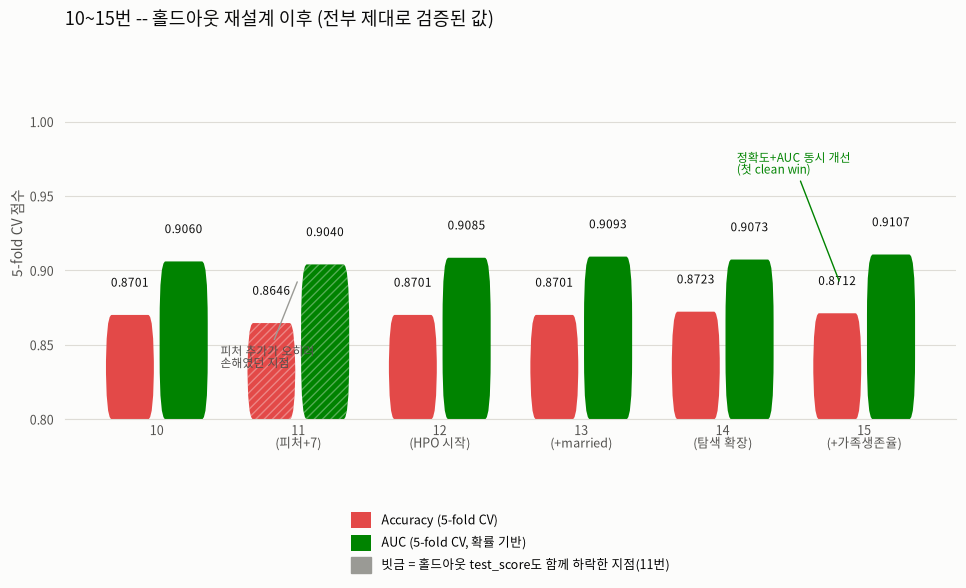

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 6.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

x = np.arange(len(labels_35))
bar_w = 0.34
gap = 0.02

for i in range(len(labels_35)):
    hatch = "////" if holdout_regressed[i] else None
    rounded_bar(ax, x[i] - bar_w/2 - gap, cv_acc_35[i] - 0.80, bar_w, COLOR_TRAIN, bottom=0.80, hatch=hatch)
    rounded_bar(ax, x[i] + bar_w/2 + gap, cv_auc_35[i] - 0.80,  bar_w, COLOR_TEST, bottom=0.80, hatch=hatch)

    ax.text(x[i] - bar_w/2 - gap, cv_acc_35[i] + 0.018, f"{cv_acc_35[i]:.4f}",
            ha="center", va="bottom", fontsize=8.5, color=TEXT_MAIN)
    ax.text(x[i] + bar_w/2 + gap, cv_auc_35[i] + 0.018, f"{cv_auc_35[i]:.4f}",
            ha="center", va="bottom", fontsize=8.5, color=TEXT_MAIN)

ax.set_xticks(x)
ax.set_xticklabels(labels_35, fontsize=9, color=TEXT_SUB)
ax.set_xlim(x[0] - 0.65, x[-1] + 0.65)
ax.set_ylim(0.80, 1.05)
ax.set_yticks(np.arange(0.80, 1.01, 0.05))
ax.tick_params(axis="y", pad=8)
ax.set_ylabel("5-fold CV 점수", fontsize=10, color=TEXT_SUB)
ax.set_title("10~15번 -- 홀드아웃 재설계 이후 (전부 제대로 검증된 값)",
              fontsize=13, color=TEXT_MAIN, pad=16, loc="left")

# 11번(회귀)과 15번(첫 clean win) 강조
ax.annotate("피처 추가가 오히려\n손해였던 지점", xy=(x[1], cv_auc_35[1] - 0.01),
            xytext=(x[1] - 0.55, 0.835), fontsize=8.5, color=TEXT_SUB,
            arrowprops=dict(arrowstyle="-", color=COLOR_MUTED, lw=1))
ax.annotate("정확도+AUC 동시 개선\n(첫 clean win)", xy=(x[5] - bar_w/2, cv_acc_35[5] + 0.02),
            xytext=(x[5] - 0.9, 0.965), fontsize=8.5, color=COLOR_TEST,
            arrowprops=dict(arrowstyle="-", color=COLOR_TEST, lw=1))

ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="y", length=0, colors=TEXT_SUB, labelsize=9)
ax.tick_params(axis="x", length=0)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_TRAIN, label="Accuracy (5-fold CV)"),
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_TEST,  label="AUC (5-fold CV, 확률 기반)"),
    plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_MUTED, hatch="////",
                  edgecolor=COLOR_MUTED, label="빗금 = 홀드아웃 test_score도 함께 하락한 지점(11번)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.22),
          ncol=1, frameon=False, fontsize=9, handlelength=1.6, handleheight=1.6)

fig.subplots_adjust(top=0.90, bottom=0.30)
plt.savefig("score_history_10_15.png", dpi=170, facecolor=SURFACE)
plt.show()


## 최종 결론 (지금까지 전체)

10~15번 시리즈에서 **정확도와 AUC를 동시에 개선한 것은 15번(가족/그룹 생존율 피처)이 유일**하다:

| 노트북 | CV Accuracy | CV AUC | 비고 |
|---|---|---|---|
| 10 | 0.8700 | 0.9060 | 홀드아웃만 고침 (기준점) |
| 11 | 0.8646 | 0.9040 | 피처 7개 추가 → 회귀 |
| 12 | 0.8700 | 0.9085 | 피처 원복 + 튜닝 시작 |
| 13 | 0.8700 | 0.9092 | `is_married_woman` 추가 |
| 14 | 0.8722 | 0.9073 | 탐색 확장 (accuracy 우선) |
| **15** | **0.8712** | **0.9106** | 가족 생존율 (**둘 다 개선**) |

지금 시점 최종 추천은 **15번** (`base_model_cv_tuned_family_0915.csv`) — 유일하게 accuracy와
AUC를 동시에 끌어올린 결과물이다. 14번은 accuracy만 보면 더 높지만(0.8722) AUC를 깎아먹은
트레이드오프라서, 어느 지표를 우선할지에 따라 선택이 갈린다.